In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error as RMSE
from sklearn.metrics import mean_squared_error
import time

In [16]:
np.random.seed(42) # to make this code example reproducible
m = 1_000_000 # number of instances
X = 2 * np.random.rand(m, 10) # column vector
y = 4 + 3 * X[:, 0] + np.random.randn(m) # column vector

In [17]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))
y_scaled = y_scaled.ravel()

**Batch**

In [18]:
sgd_batch = SGDRegressor(random_state=42)
start = time.time()
sgd_batch.fit(X_scaled, y_scaled)
end = time.time()
batch_time = end - start

y_pred_batch = sgd_batch.predict(X_scaled)
rmse_batch = RMSE(y_scaled, y_pred_batch)
rmse_batch

0.499797158326477

**MINI Batch**

In [ ]:
sgd_mb = SGDRegressor(random_state=42, warm_start=True)

batch_size = 1000
n_epochs = 10
tol = 0.1
n_iter_no_change = 5

inxs = np.random.permutation(m)
last_epoch_mse = None
n_iter_no_change_counter = 0

start = time.time()
for epoch in range(n_epochs):
    X_shuffled = X_scaled[inxs]
    y_shuffled = y_scaled[inxs]

    epoch_mse = 0
    n_batches = 0

    for iter in range(0, m, batch_size):
        Xi = X_shuffled[iter:iter + 1]
        yi = y_shuffled[iter:iter + 1]
        sgd_mb.partial_fit(Xi, yi)

        # y_pred = sgd_mb.predict(Xi)
        # batch_mse = mean_squared_error(yi, y_pred)
        # epoch_mse += batch_mse
        # n_batches += 1

    np.random.shuffle(inxs)
    
    # epoch_mse /= n_batches
    # if last_epoch_mse is None:
    #     last_epoch_mse = epoch_mse
    #     continue

    # if np.abs(last_epoch_mse - epoch_mse) < tol:
    #     n_iter_no_change_counter += 1

    #     if n_iter_no_change_counter == n_iter_no_change:
    #         break

    # else:
    #     n_iter_no_change_counter = 0



end = time.time()
mini_batch_time = end - start

y_pred_minibatch = sgd_mb.predict(X_scaled)
rmse_minibatch = RMSE(y_scaled, y_pred_minibatch)
rmse_minibatch

0.5010744154133052

**results**

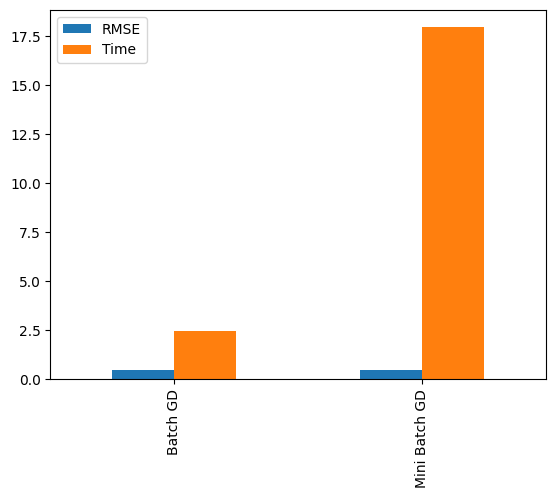

,RMSE,Time
Batch GD,0.499797,2.476754
Mini Batch GD,0.501074,17.944178


In [30]:
cols = ['RMSE', 'Time']
rows = ['Batch GD', 'Mini Batch GD']
data = [
    [rmse_batch, batch_time],
    [rmse_minibatch, mini_batch_time],
]

results = pd.DataFrame(data, rows, cols)
results.plot.bar()
plt.show()
results